<a href="https://colab.research.google.com/github/Kgodiso-Leboho/GameVault-Aquisition-Intelligence-System/blob/main/exploratory_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("/content/sample_data/cleaned_steam_reviews 1.csv")
df.head()

,date_posted,funny,helpful,hour_played,is_early_access_review,recommendation,review,title
0,2018-11-24,0,0,40,False,Recommended,10/10 would murder kids again,rust
1,2016-06-28,0,0,20,False,Recommended,oh yeah,euro truck simulator 2
2,2016-01-09,0,0,292,True,Recommended,is good gam,rust
3,2018-07-08,0,0,401,False,Recommended,spooky.,dead by daylight
4,2018-12-29,1,1,125,False,Not Recommended,tries to play for an hour with my bros.had to ...,grand theft auto v


In [9]:
df['hour_played'].describe()


,hour_played
count,14610.000000
mean,296.132991
std,510.083177
min,0.000000
25%,33.250000
50%,122.000000
75%,340.000000
max,9567.000000


In [10]:
df['funny'].describe()


,funny
count,14610.000000
mean,1.113142
std,45.546371
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,5274.000000


In [11]:
df['helpful'].describe()

,helpful
count,14610.000000
mean,3.716769
std,58.754482
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,2464.000000


In [12]:
df['recommendation'].value_counts()
df['recommendation'].value_counts(normalize=True) * 100

,proportion
recommendation,
Recommended,71.115674
Not Recommended,28.884326


In [14]:
df['title'].value_counts().head(20)

,count
title,
playerunknown's battlegrounds,2538
rust,2290
grand theft auto v,2173
rocket league®,1772
dead by daylight,1034
the elder scrolls v: skyrim special edition,976
monster hunter: world,774
astroneer,576
resident evil 2 / biohazard re:2,496


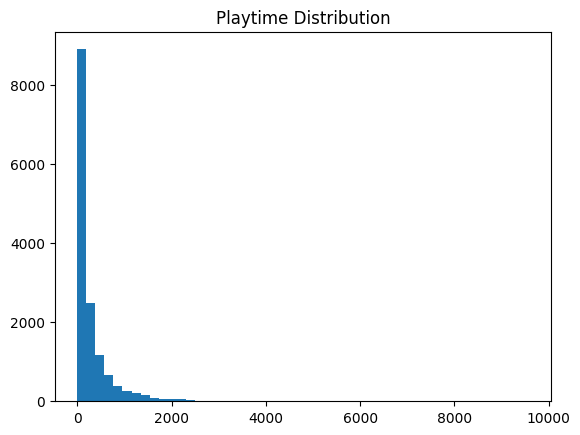

In [15]:
plt.hist(df['hour_played'], bins=50)
plt.title("Playtime Distribution")
plt.show()

In [16]:
game_df = df.groupby('title').agg(
    avg_playtime=('hour_played', 'mean'),
    total_reviews=('review', 'count'),
    helpful_votes=('helpful', 'sum'),
    funny_votes=('funny', 'sum'),
    recommendation_rate=('recommendation', lambda x: (x == 'Recommended').mean())
).reset_index()

<Axes: xlabel='avg_playtime', ylabel='recommendation_rate'>

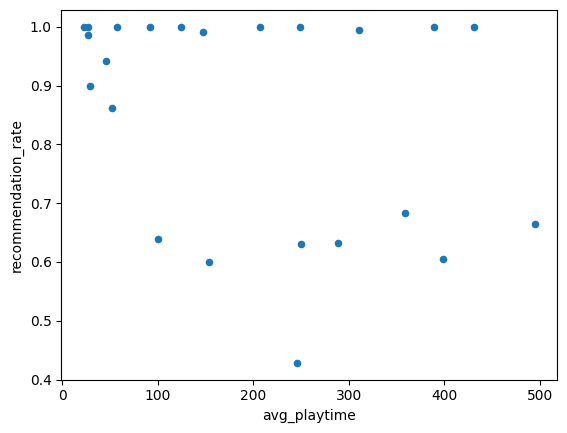

In [17]:
game_df.plot.scatter(
    x='avg_playtime',
    y='recommendation_rate'
)

<Axes: xlabel='total_reviews', ylabel='recommendation_rate'>

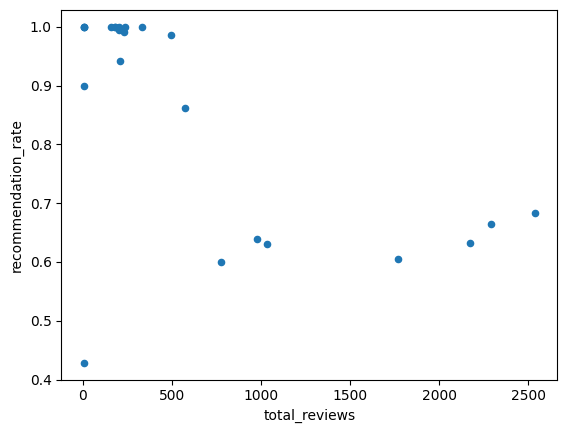

In [18]:
game_df.plot.scatter(
    x='total_reviews',
    y='recommendation_rate'
)

<Axes: xlabel='helpful_votes', ylabel='avg_playtime'>

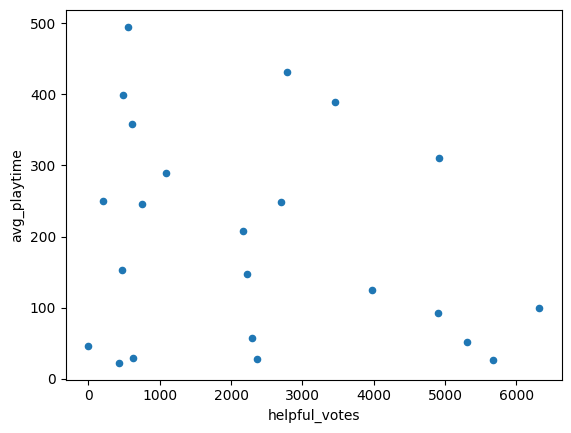

In [19]:
game_df.plot.scatter(
    x='helpful_votes',
    y='avg_playtime'
)